#### 04_ml.ipynb

In [4]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np

from neo4j import GraphDatabase

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")


In [6]:
import os

print(os.getcwd())

/Users/rudrapibgle/GIT projects/BigData_and_BI_CapstoneProject/notebooks


In [7]:
df = pd.read_parquet(
    "../data/clean/supply_chain.parquet"
)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (180519, 23)


,order_id,customer_id,product_name,category,department,Product Price,product_image,Order Region,Market,Order Status,...,sales,quantity,profit,Latitude,Longitude,delay,view_count,unique_users,peak_month,peak_hour
0,77202,20755,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,Southeast Asia,Pacific Asia,COMPLETE,...,327.75,1,91.250000,18.251453,-66.037056,-1.0,0.0,0.0,None,NaN
1,75939,19492,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,South Asia,Pacific Asia,PENDING,...,327.75,1,-249.089996,18.279451,-66.037064,1.0,0.0,0.0,None,NaN
2,75938,19491,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,South Asia,Pacific Asia,CLOSED,...,327.75,1,-247.779999,37.292233,-121.881279,0.0,0.0,0.0,None,NaN
3,75937,19490,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,Oceania,Pacific Asia,COMPLETE,...,327.75,1,22.860001,34.125946,-118.291016,-1.0,0.0,0.0,None,NaN
4,75936,19489,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,Oceania,Pacific Asia,PENDING_PAYMENT,...,327.75,1,134.210007,18.253769,-66.037048,-2.0,0.0,0.0,None,NaN


In [8]:
print("\n================ INFO ================\n")
print(df.info())

print("\n================ NULL VALUES ================\n")
print(df.isnull().sum())

print("\n================ COLUMNS ================\n")
print(df.columns.tolist())


================ INFO ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        180519 non-null  object 
 1   customer_id     180519 non-null  object 
 2   product_name    180519 non-null  object 
 3   category        180519 non-null  object 
 4   department      180519 non-null  object 
 5   Product Price   180519 non-null  float64
 6   product_image   180519 non-null  object 
 7   Order Region    180519 non-null  object 
 8   Market          180519 non-null  object 
 9   Order Status    180519 non-null  object 
 10  Shipping Mode   180519 non-null  object 
 11  actual_days     180519 non-null  float64
 12  scheduled_days  180519 non-null  float64
 13  sales           180519 non-null  float64
 14  quantity        180519 non-null  int32  
 15  profit          180519 non-null  float64
 16  Latitude       

In [9]:
URI = "bolt://localhost:7687"

USERNAME = "neo4j"

PASSWORD = "Swara@1212"


driver = GraphDatabase.driver(
    URI,
    auth=(USERNAME, PASSWORD)
)

print("Neo4j Connected Successfully")


Neo4j Connected Successfully


In [10]:

# Order-level graph features
# because prediction target = delayed order or not

degree_query = """
MATCH (n:Order)

OPTIONAL MATCH (n)-[r]-()

RETURN
    n.order_id AS node_id,

    COUNT(r) AS degree,

    COUNT { (n)-[]->() } AS out_degree,

    COUNT { (n)<-[]-() } AS in_degree
"""


# Run Cypher query

with driver.session() as session:

    result = session.run(degree_query)

    degree_data = [record.data() for record in result]


# Convert Neo4j output to pandas DataFrame

degree_df = pd.DataFrame(degree_data)


# Display results

print("Degree Features Extracted Successfully")

print("Shape:", degree_df.shape)

degree_df.head()

Degree Features Extracted Successfully
Shape: (65752, 4)


,node_id,degree,out_degree,in_degree
0,41777,7,7,0
1,27559,3,3,0
2,47394,3,3,0
3,30336,4,4,0
4,20602,5,5,0


In [11]:
print("DF Columns:", df.columns.tolist())
print("Degree DF Columns:", degree_df.columns.tolist())

DF Columns: ['order_id', 'customer_id', 'product_name', 'category', 'department', 'Product Price', 'product_image', 'Order Region', 'Market', 'Order Status', 'Shipping Mode', 'actual_days', 'scheduled_days', 'sales', 'quantity', 'profit', 'Latitude', 'Longitude', 'delay', 'view_count', 'unique_users', 'peak_month', 'peak_hour']
Degree DF Columns: ['node_id', 'degree', 'out_degree', 'in_degree']


In [12]:

if "node_id" not in df.columns:
    df["node_id"] = df.index.astype(str)

df["node_id"] = df["node_id"].astype(str)
degree_df["node_id"] = degree_df["node_id"].astype(str)

In [13]:
merged_df = pd.merge(
    df,
    degree_df,
    how="left",
    on="node_id"
)

print("Merge Successful")

print("Merged Shape:", merged_df.shape)

merged_df.head()

Merge Successful
Merged Shape: (180519, 27)


,order_id,customer_id,product_name,category,department,Product Price,product_image,Order Region,Market,Order Status,...,Longitude,delay,view_count,unique_users,peak_month,peak_hour,node_id,degree,out_degree,in_degree
0,77202,20755,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,Southeast Asia,Pacific Asia,COMPLETE,...,-66.037056,-1.0,0.0,0.0,None,NaN,0,NaN,NaN,NaN
1,75939,19492,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,South Asia,Pacific Asia,PENDING,...,-66.037064,1.0,0.0,0.0,None,NaN,1,3.0,3.0,0.0
2,75938,19491,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,South Asia,Pacific Asia,CLOSED,...,-121.881279,0.0,0.0,0.0,None,NaN,2,5.0,5.0,0.0
3,75937,19490,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,Oceania,Pacific Asia,COMPLETE,...,-118.291016,-1.0,0.0,0.0,None,NaN,3,NaN,NaN,NaN
4,75936,19489,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,Oceania,Pacific Asia,PENDING_PAYMENT,...,-66.037048,-2.0,0.0,0.0,None,NaN,4,6.0,6.0,0.0


In [14]:
df["node_id"] = df["order_id"].astype(str)

degree_df["node_id"] = degree_df["node_id"].astype(str)

print("node_id Created Successfully")

df[["order_id", "node_id"]].head()

node_id Created Successfully


,order_id,node_id
0,77202,77202
1,75939,75939
2,75938,75938
3,75937,75937
4,75936,75936


In [15]:
# HANDLE MISSING VALUES

# Graph feature columns

degree_cols = [
    "degree",
    "out_degree",
    "in_degree"
]

for col in degree_cols:

    merged_df[col] = merged_df[col].fillna(0)


# Numerical columns

num_cols = merged_df.select_dtypes(
    include=np.number
).columns

for col in num_cols:

    merged_df[col].fillna(
        merged_df[col].median(),
        inplace=True
    )


# Categorical columns

cat_cols = merged_df.select_dtypes(
    include="object"
).columns

for col in cat_cols:

    merged_df[col].fillna(
        merged_df[col].mode()[0],
        inplace=True
    )

print("Missing Values Handled Successfully")

Missing Values Handled Successfully


In [16]:
# DEFINE TARGET COLUMN

# Delay prediction target

target_column = "delay"

print("Target Column:", target_column)

Target Column: delay


In [17]:
#  CREATE FEATURE MATRIX & TARGET

# node_id is merge key ONLY
# not a model feature

drop_cols = [
    "node_id"
]

X = merged_df.drop(
    columns=drop_cols + [target_column]
)

y = merged_df[target_column]

print("Feature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Matrix Shape: (180519, 25)
Target Shape: (180519,)


In [18]:
# IDENTIFY FEATURE TYPES

numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numeric Columns:")
print(numeric_cols)

print()

print("Categorical Columns:")
print(categorical_cols)

Numeric Columns:
['Product Price', 'actual_days', 'scheduled_days', 'sales', 'quantity', 'profit', 'Latitude', 'Longitude', 'view_count', 'unique_users', 'peak_hour', 'degree', 'out_degree', 'in_degree']

Categorical Columns:
['order_id', 'customer_id', 'product_name', 'category', 'department', 'product_image', 'Order Region', 'Market', 'Order Status', 'Shipping Mode', 'peak_month']


In [19]:

# TRAIN TEST SPLIT

# IMPORTANT:
# Split BEFORE preprocessing
# prevents DATA LEAKAGE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Completed")

print("X_train Shape:", X_train.shape)

print("X_test Shape:", X_test.shape)

Train-Test Split Completed
X_train Shape: (144415, 25)
X_test Shape: (36104, 25)


In [20]:

# COLUMN TRANSFORMER

# Preprocessing INSIDE pipeline

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_cols
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

print("ColumnTransformer Created Successfully")

ColumnTransformer Created Successfully


In [21]:
# CREATE ML PIPELINE

pipe = Pipeline([

    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",

        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    )
])

print("ML Pipeline Created Successfully")

ML Pipeline Created Successfully


In [22]:
# TRAIN MODEL

pipe.fit(
    X_train,
    y_train
)

print("Model Training Completed")

Model Training Completed


In [23]:
# PREDICTIONS

y_pred = pipe.predict(X_test)

print("Predictions Completed")

Predictions Completed


In [24]:
# MODEL EVALUATION

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n================ ACCURACY ================\n")

print(accuracy)

print("\n================ CLASSIFICATION REPORT ================\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\n================ CONFUSION MATRIX ================\n")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


================ ACCURACY ================

0.9993906492355418

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

        -2.0       1.00      1.00      1.00      4333
        -1.0       1.00      1.00      1.00      4340
         0.0       1.00      1.00      1.00      6751
         1.0       1.00      1.00      1.00     12129
         2.0       1.00      1.00      1.00      5744
         3.0       1.00      1.00      1.00      1410
         4.0       1.00      1.00      1.00      1397

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104


================ CONFUSION MATRIX ================

[[ 4333     0     0     0     0     0     0]
 [    0  4340     0     0     0     0     0]
 [    0     5  6741     4     1     0     0]
 [    0     2     1 12126     0     0     0]
 [    0     0     0     1  5738     5     0]
 [ 

In [25]:
# FEATURE IMPORTANCE

classifier = pipe.named_steps["classifier"]

encoded_cat_features = pipe.named_steps[
    "preprocessor"
].named_transformers_[
    "cat"
].get_feature_names_out(
    categorical_cols
)

all_features = (
    numeric_cols +
    list(encoded_cat_features)
)

feature_importance = pd.DataFrame({

    "Feature": all_features,

    "Importance": classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n================ TOP FEATURES ================\n")

print(
    feature_importance.head(20)
)


================ TOP FEATURES ================

                            Feature  Importance
1                       actual_days    0.381711
2                    scheduled_days    0.060400
80450     Shipping Mode_First Class    0.046129
80453  Shipping Mode_Standard Class    0.041324
80452    Shipping Mode_Second Class    0.025976
6                          Latitude    0.014816
5                            profit    0.014433
7                         Longitude    0.014333
80451        Shipping Mode_Same Day    0.006853
3                             sales    0.005488
4                          quantity    0.004401
11                           degree    0.003867
12                       out_degree    0.003855
80443         Order Status_COMPLETE    0.002697
80447  Order Status_PENDING_PAYMENT    0.002489
0                     Product Price    0.002252
8                        view_count    0.002031
9                      unique_users    0.002018
80442           Order Status_CLOSED    

In [26]:
#  SAVE FEATURE IMPORTANCE

feature_importance.to_csv(
    "../data/clean/feature_importance.csv",
    index=False
)

print("Feature Importance Saved")

Feature Importance Saved


In [27]:
# SAVE MERGED ML DATASET

merged_df.to_parquet(
    "../data/clean/ml_merged_dataset.parquet",
    index=False
)

merged_df.to_csv(
    "../data/clean/ml_merged_dataset.csv",
    index=False
)

print("Merged ML Dataset Saved Successfully")

Merged ML Dataset Saved Successfully


In [28]:
import joblib

In [29]:

#  SAVE ML PIPELINE MODEL

import joblib

joblib.dump(
    pipe,
    "../data/clean/baseline_ml_pipeline.pkl"
)

print("ML Pipeline Saved Successfully")

ML Pipeline Saved Successfully


In [30]:

# SAVE PREDICTIONS

predictions_df = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred
})

predictions_df.to_csv(
    "../data/clean/predictions.csv",
    index=False
)

print("Predictions Saved Successfully")

Predictions Saved Successfully


In [31]:

# CLOSE NEO4J CONNECTION

driver.close()

print("Neo4j Connection Closed")

Neo4j Connection Closed


#### PART 2 — ENRICH 04_ml.ipynb

In [32]:
import pandas as pd

gds_features = pd.read_csv(
    "../data/clean/gds_features.csv"
)

print(gds_features.shape)

display(gds_features.head())

(65752, 3)


,node_id,pagerank,community
0,41777,0.721510,50
1,27559,0.408641,168
2,47394,0.399931,41
3,30336,0.487441,168
4,20602,0.568930,91


In [33]:
# Convert both node_id columns to string

df["node_id"] = df["node_id"].astype(str)

gds_features["node_id"] = gds_features["node_id"].astype(str)

In [34]:
# merge graph features with ML dataset

enriched = pd.merge(

    df,

    gds_features,

    how="left",

    on="node_id"
)

print(enriched.shape)

display(enriched.head())

(180519, 26)


,order_id,customer_id,product_name,category,department,Product Price,product_image,Order Region,Market,Order Status,...,Latitude,Longitude,delay,view_count,unique_users,peak_month,peak_hour,node_id,pagerank,community
0,77202,20755,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,Southeast Asia,Pacific Asia,COMPLETE,...,18.251453,-66.037056,-1.0,0.0,0.0,None,NaN,77202,0.430720,168
1,75939,19492,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,South Asia,Pacific Asia,PENDING,...,18.279451,-66.037064,1.0,0.0,0.0,None,NaN,75939,0.429272,168
2,75938,19491,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,South Asia,Pacific Asia,CLOSED,...,37.292233,-121.881279,0.0,0.0,0.0,None,NaN,75938,0.429272,168
3,75937,19490,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,Oceania,Pacific Asia,COMPLETE,...,34.125946,-118.291016,-1.0,0.0,0.0,None,NaN,75937,0.429128,168
4,75936,19489,smart watch,sporting goods,Fitness,327.75,http://images.acmesports.sports/Smart+watch,Oceania,Pacific Asia,PENDING_PAYMENT,...,18.253769,-66.037048,-2.0,0.0,0.0,None,NaN,75936,0.429128,168


In [35]:
enriched["pagerank"] = enriched[
    "pagerank"
].fillna(0)

enriched["community"] = enriched[
    "community"
].fillna(-1)

enriched["community"] = enriched[
    "community"
].astype(int)

In [36]:
print(enriched.columns)

Index(['order_id', 'customer_id', 'product_name', 'category', 'department',
       'Product Price', 'product_image', 'Order Region', 'Market',
       'Order Status', 'Shipping Mode', 'actual_days', 'scheduled_days',
       'sales', 'quantity', 'profit', 'Latitude', 'Longitude', 'delay',
       'view_count', 'unique_users', 'peak_month', 'peak_hour', 'node_id',
       'pagerank', 'community'],
      dtype='object')


In [37]:
#Create BASELINE Dataset
baseline_df = enriched.drop(

    columns=[
        "pagerank",
        "community"
    ]
)

In [38]:
# Create BASELINE Dataset
enriched_df = enriched.copy()

In [39]:
# Define Target Column
target = "delay"

In [40]:
# ============================================================
# BASELINE DATA
# ============================================================

X_baseline = baseline_df.drop(
    columns=[target]
)

y_baseline = baseline_df[target]

In [41]:
## BASELINE
X_baseline = baseline_df.drop(
    columns=[target]
)

y_baseline = baseline_df[target]

In [42]:
#Enriched
X_enriched = enriched_df.drop(
    columns=[target]
)

y_enriched = enriched_df[target]

In [43]:
# Train Test Split
from sklearn.model_selection import train_test_split

In [44]:
# BASELINE

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(

    X_baseline,
    y_baseline,

    test_size=0.2,

    random_state=42,

    stratify=y_baseline
)


# ENRICHED

X_train_enr, X_test_enr, y_train_enr, y_test_enr = train_test_split(

    X_enriched,
    y_enriched,

    test_size=0.2,

    random_state=42,

    stratify=y_enriched
)

In [45]:
print(X_train_base.isna().sum().sum())

print(X_train_enr.isna().sum().sum())

20048
20048


In [46]:
# Define Columns
# Baseline Numeric
baseline_numeric_cols = [

    "Product Price",
    "sales",
    "quantity",
    "profit",
    "Latitude",
    "Longitude",
    "view_count",
    "unique_users"
]

In [47]:
#Baseline Categorical
baseline_categorical_cols = [

    "category",
    "department",
    "Order Region",
    "Market",
    "Shipping Mode",
    "Order Status"
]

In [48]:
# Add Graph Features
# Enriched Numeric
enriched_numeric_cols = baseline_numeric_cols + [
    "pagerank"
]

In [49]:
#Enriched Categorical
enriched_categorical_cols = baseline_categorical_cols + [
    "community"
]

In [50]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

In [51]:
#Build BASELINE Pipeline
baseline_preprocessor = ColumnTransformer([

    (
        "num",
        StandardScaler(),
        baseline_numeric_cols
    ),

    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        baseline_categorical_cols
    )
])


baseline_pipe = Pipeline([

    (
        "preprocessor",
        baseline_preprocessor
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    )
])

In [52]:
#Build ENRICHED Pipeline
enriched_preprocessor = ColumnTransformer([

    (
        "num",
        StandardScaler(),
        enriched_numeric_cols
    ),

    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        enriched_categorical_cols
    )
])


enriched_pipe = Pipeline([

    (
        "preprocessor",
        enriched_preprocessor
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    )
])

In [53]:
#Train BOTH Models
baseline_pipe.fit(
    X_train_base,
    y_train_base
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
enriched_pipe.fit(
    X_train_enr,
    y_train_enr
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
#Predictions
baseline_preds = baseline_pipe.predict(
    X_test_base
)

enriched_preds = enriched_pipe.predict(
    X_test_enr
)

In [56]:
#Classification Reports
from sklearn.metrics import classification_report

In [57]:
#Baseline Report
print("BASELINE MODEL\n")

print(

    classification_report(
        y_test_base,
        baseline_preds
    )
)

BASELINE MODEL

              precision    recall  f1-score   support

        -2.0       0.28      0.28      0.28      4333
        -1.0       0.28      0.28      0.28      4340
         0.0       0.35      0.36      0.35      6751
         1.0       0.65      0.64      0.64     12129
         2.0       0.29      0.29      0.29      5744
         3.0       0.31      0.31      0.31      1410
         4.0       0.32      0.31      0.31      1397

    accuracy                           0.42     36104
   macro avg       0.35      0.35      0.35     36104
weighted avg       0.42      0.42      0.42     36104



In [58]:
#Enriched Report
print("ENRICHED MODEL\n")

print(

    classification_report(
        y_test_enr,
        enriched_preds
    )
)

ENRICHED MODEL

              precision    recall  f1-score   support

        -2.0       0.42      0.43      0.43      4333
        -1.0       0.43      0.43      0.43      4340
         0.0       0.50      0.50      0.50      6751
         1.0       0.73      0.72      0.72     12129
         2.0       0.45      0.45      0.45      5744
         3.0       0.50      0.51      0.51      1410
         4.0       0.52      0.49      0.50      1397

    accuracy                           0.55     36104
   macro avg       0.51      0.51      0.51     36104
weighted avg       0.55      0.55      0.55     36104



In [59]:
#Comparison Metrics
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score
)

In [60]:
#Calculate Metrics Dynamically
baseline_accuracy = accuracy_score(
    y_test_base,
    baseline_preds
)

enriched_accuracy = accuracy_score(
    y_test_enr,
    enriched_preds
)

In [61]:
baseline_precision = precision_score(
    y_test_base,
    baseline_preds,
    average="weighted"
)

enriched_precision = precision_score(
    y_test_enr,
    enriched_preds,
    average="weighted"
)

In [62]:
baseline_recall = recall_score(
    y_test_base,
    baseline_preds,
    average="weighted"
)

enriched_recall = recall_score(
    y_test_enr,
    enriched_preds,
    average="weighted"
)

In [63]:
baseline_f1 = f1_score(
    y_test_base,
    baseline_preds,
    average="weighted"
)

enriched_f1 = f1_score(
    y_test_enr,
    enriched_preds,
    average="weighted"
)

In [64]:
#Final Comparison Table
comparison = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Baseline": [

        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],

    "Enriched": [

        enriched_accuracy,
        enriched_precision,
        enriched_recall,
        enriched_f1
    ]
})


comparison["Delta"] = (

    comparison["Enriched"]

    -

    comparison["Baseline"]
)

comparison = comparison.round(4)

comparison

,Metric,Baseline,Enriched,Delta
0,Accuracy,0.4190,0.5507,0.1318
1,Precision,0.4196,0.5518,0.1322
2,Recall,0.4190,0.5507,0.1318
3,F1 Score,0.4193,0.5512,0.1320


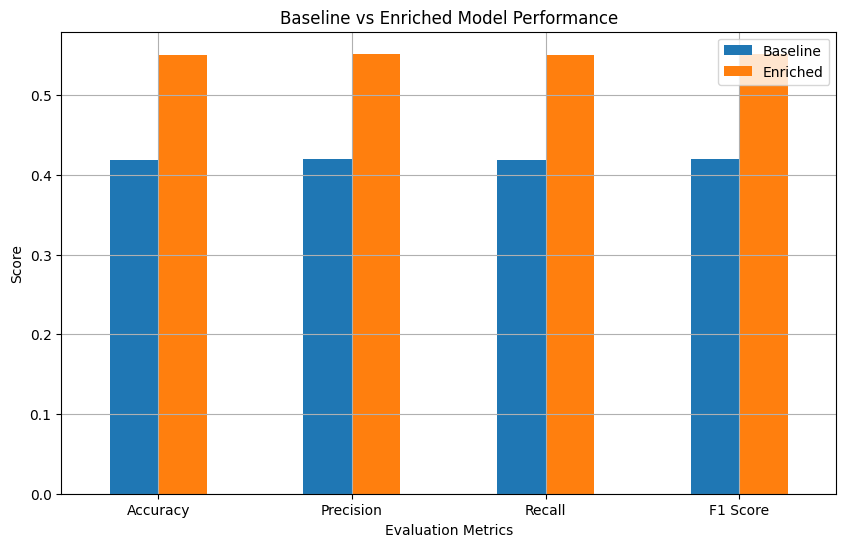

In [65]:
# VISUALIZATION — BASELINE vs ENRICHED MODEL

import matplotlib.pyplot as plt

# Create bar chart

comparison.plot(

    x="Metric",

    y=["Baseline", "Enriched"],

    kind="bar",

    figsize=(10, 6)
)

# Chart title

plt.title(
    "Baseline vs Enriched Model Performance"
)

# Axis labels

plt.xlabel("Evaluation Metrics")

plt.ylabel("Score")

# Rotate labels

plt.xticks(rotation=0)

# Add grid

plt.grid(True)

# Show chart

plt.show()

In [66]:
%who

ColumnTransformer	 GraphDatabase	 OneHotEncoder	 PASSWORD	 Pipeline	 RandomForestClassifier	 StandardScaler	 URI	 USERNAME	 
X	 X_baseline	 X_enriched	 X_test	 X_test_base	 X_test_enr	 X_train	 X_train_base	 X_train_enr	 
accuracy	 accuracy_score	 all_features	 baseline_accuracy	 baseline_categorical_cols	 baseline_df	 baseline_f1	 baseline_numeric_cols	 baseline_pipe	 
baseline_precision	 baseline_preds	 baseline_preprocessor	 baseline_recall	 cat_cols	 categorical_cols	 classification_report	 classifier	 col	 
comparison	 confusion_matrix	 degree_cols	 degree_data	 degree_df	 degree_query	 df	 driver	 drop_cols	 
encoded_cat_features	 enriched	 enriched_accuracy	 enriched_categorical_cols	 enriched_df	 enriched_f1	 enriched_numeric_cols	 enriched_pipe	 enriched_precision	 
enriched_preds	 enriched_preprocessor	 enriched_recall	 f1_score	 feature_importance	 gds_features	 joblib	 merged_df	 np	 
num_cols	 numeric_cols	 os	 pd	 pipe	 plt	 precision_score	 predictions_df	 preprocessor	 

In [68]:
import os

os.makedirs(
    "../models",
    exist_ok=True
)

In [69]:
joblib.dump(
    enriched_pipe,
    "../models/enriched_model.pkl"
)

['../models/enriched_model.pkl']

In [ ]:
 # LOAD GRAPH FEATURES
gds_features = pd.read_csv(
    "../data/clean/gds_features.csv"
)

In [71]:
#LOAD MAIN DATASET
df = pd.read_parquet(
    "../data/clean/ml_merged_dataset.parquet"
)

In [72]:
#FIX DATA TYPES
df["node_id"] = df["node_id"].astype(int)

gds_features["node_id"] = gds_features["node_id"].astype(int)

In [73]:
#MERGE
df = pd.merge(

    df,

    gds_features,

    on="node_id",

    how="left"
)

In [74]:
#VERIFY
df.columns

Index(['order_id', 'customer_id', 'product_name', 'category', 'department',
       'Product Price', 'product_image', 'Order Region', 'Market',
       'Order Status', 'Shipping Mode', 'actual_days', 'scheduled_days',
       'sales', 'quantity', 'profit', 'Latitude', 'Longitude', 'delay',
       'view_count', 'unique_users', 'peak_month', 'peak_hour', 'node_id',
       'degree', 'out_degree', 'in_degree', 'pagerank', 'community'],
      dtype='object')

In [75]:
df.to_parquet(

    "../data/clean/ml_merged_dataset.parquet",

    index=False
)

print("Updated dataset saved successfully.")

Updated dataset saved successfully.
